이전 [데이터분석 기초 복습](./2026-05-22_data_analysis_basic_review.ipynb)에서 이어집니다.
# 첨도와 왜도
왜도(skewness)와 치우친 분포(skewed distribution)은 **데이터 분포가 한쪽으로 치우친 정도를 말합니다.**

이전에 쓰던 데이터셋, `[45, 50, 52, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 95, 100, 150]` 에서는 




0    -1.374855
1    -1.153817
2    -1.065402
3    -0.932779
4    -0.711742
5    -0.623327
6    -0.490704
7    -0.358081
8    -0.269666
9    -0.181251
10   -0.048628
11    0.083994
12    0.172409
13    0.260825
14    0.393447
15    0.526070
16    0.614485
17    0.835523
18    1.056561
19    3.266939
dtype: float64


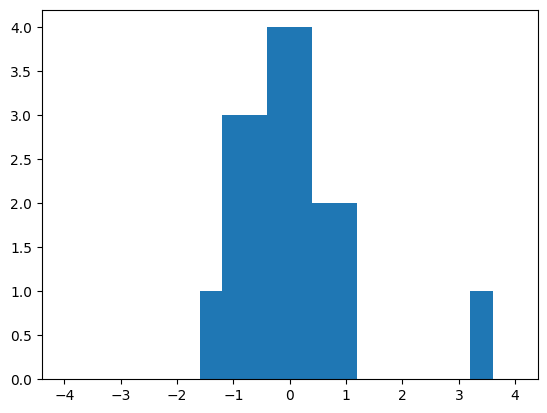

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

s = pd.Series([45, 50, 52, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 95, 100, 150])

s_mean = s.mean()
s_median = s.median()
s_std = s.std(ddof=0)

z_scores = (s - s_mean)/s_std
print(z_scores)
plt.hist(z_scores, bins=20, range=(-4, 4), histtype='stepfilled')
plt.show()


위의 표에서는 중앙/왼쪽으로 데이터가 많으며 오른쪽에 튀는 데이터가 하나 있는 모습이다.

이걸 우리는 
- `right-skewed distribution` (오른쪽 꼬리가 긴 분포)
- `positive skew` (양의 왜도)

라고 부른다.

0   -2.651319
1   -0.701820
2   -0.311920
3    0.077980
4    0.272930
5    0.467880
6    0.545860
7    0.662830
8    0.779800
9    0.857780
dtype: float64


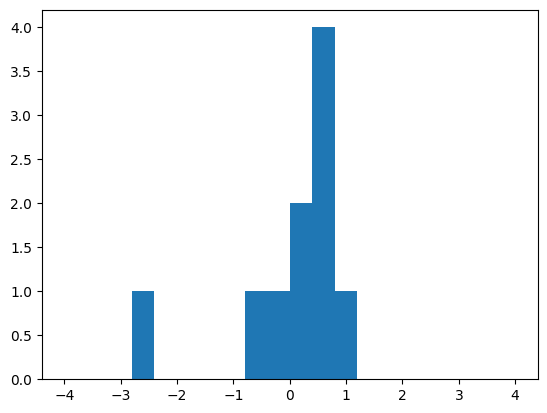

In [13]:
# 다른 예시
s = pd.Series([0, 50, 60, 70, 75, 80, 82, 85, 88, 90])

s_mean = s.mean()
s_median = s.median()
s_std = s.std(ddof=0)

z_scores = (s - s_mean)/s_std
print(z_scores)
plt.hist(z_scores, bins=20, range=(-4, 4), histtype='stepfilled')
plt.show()

위와 같은 경우에는 
- `left-skewed distribution`
- `negative skew` 

라고 부릅니다.
`data = [0, 50, 60, 70, 75, 80, 82, 85, 88, 90]` 에서 대부분 50~90 사이에 있는데 0이 하나 존재하기 때문입니다.

---

# 평균, 중앙값, 왜도

# 왜도
- 오른쪽 왜도(오른쪽에 튀는 값이 존재): `최빈값 < 중앙값 < 평균` 인 경우입니다. (평균이 중앙값보다 민감해서)
- 왼쪽 왜도(왼쪽에 튀는값이 존재): `평균 < 중앙값 < 최빈값`입니다.

> 예를 들어서 소득 데이터는 보통 일부 사람이 소득을 견인하는 특성에 의해 오른쪽 왜도가 많은 편입니다.

> 서버 요청의 경우에도 일부 오래걸리는 작업이 평균을 견인하여 중앙값이 더 신뢰도 있는 경우가 있습니다.

# 첨도

왜도는 종모양이 좌우 중 어느쪽으로 기울었는지를 확인한다면 **첨도(Kurtosis)는 종모양이 얼마나 값들이 극단적으로 나타나는지**를 나타내는 값입니다.

> 예시로 투자 수익률 데이터에서 첨도가 높으면 대부분 작은변동, 종종 큰 변동성
> 반대로 낮은 첨도면 어느정도 편차는 있지만 일정한 변동성을 의미합니다.

0   -0.878759
1   -0.704402
2   -0.634659
3   -0.530045
4   -0.355688
5   -0.181331
6   -0.006974
7    0.167383
8    0.341739
9    2.782735
dtype: float64


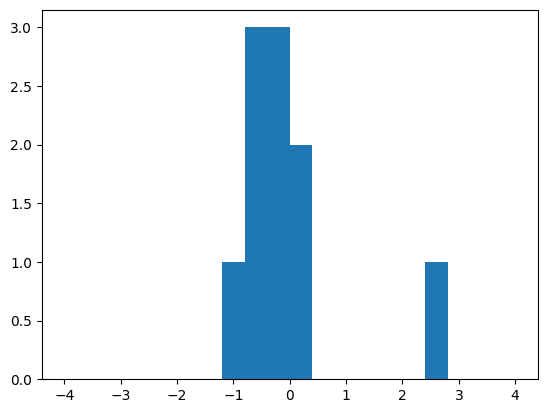

6.458571119395871
2.384683619113449


In [ ]:
s = pd.Series([45, 50, 52, 55, 60, 65, 70, 75, 80, 150])

s_mean = s.mean()
s_median = s.median()
s_std = s.std(ddof=0)

z_scores = (s - s_mean)/s_std
print(z_scores)
plt.hist(z_scores, bins=20, range=(-4, 4), histtype='stepfilled')
plt.show()

print(s.kurt()) # 6.45... 으로 극단값이 높게 나옴.
print(s.skew()) # 2.38... 으로 오른쪽 꼬리

0   -1.179789
1   -1.104161
2   -0.952906
3   -0.726024
4   -0.347886
5    0.030251
6    0.408388
7    0.786526
8    1.164663
9    1.920938
dtype: float64


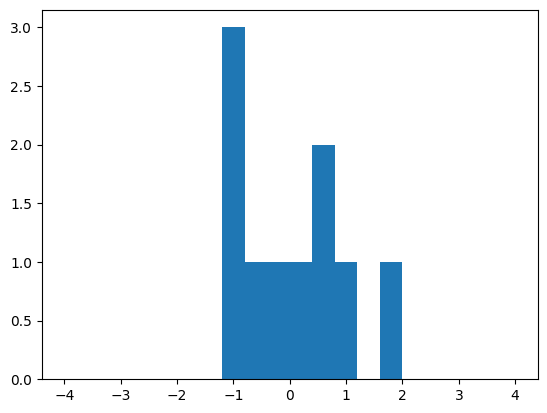

-0.7315599225380587
0.5863320817136408


In [ ]:
s = pd.Series([49, 50, 52, 55, 60, 65, 70, 75, 80, 90])

s_mean = s.mean()
s_median = s.median()
s_std = s.std(ddof=0)

z_scores = (s - s_mean)/s_std
print(z_scores)
plt.hist(z_scores, bins=20, range=(-4, 4), histtype='stepfilled')
plt.show()

print(s.kurt()) # -0.73... 으로 상대적으로 완만하며 극단값 영향이 적음
print(s.skew()) # 0.58... 으로 오른쪽으로 치우치지만 심하지 않음

# 스케일링
스케일링은 숫자의 범위를 맞추는 작업입니다.

예를 들어서 
- 나이: 1~99
- 연봉: 2800~10000
- 공부시간: 1~10

등과 같이 숫자 범위가 달라서 머신러이 모델이나 거리 계상에서는 숫자 크기가 더 큰 변수가 영향을 더 많이 줄 있습니다.

위의 데이터에서 데이터 상으로 보면 `1 > 99` 되었을 때 `2800 > 10000` 으로 변화 비율이 `98:7200` 식으로 뻥튀기 될 수 있습니다. 

또한 거리를 적용할 때에도 거리공식에서 나이가 연봉에 비에 영향을 주는 비율이 너무 적어질 있어 최종적으로 나이는 중요한 데이터가 아니라는 판단이 내려질 수 있습니다.

# 정규화
이 때문에 데이터를 보통 `0`~`1` 사이로 바꾸게 됩니다. 가장 대표적인 것이 `Min-Max` 정규화 입니다.

공식은 다음과 같습니다.

`(값 - 최솟값) / (최댓값 - 최솟값)`

예를 들어서 정규화를 해보겠습니다.

```

데이터: [2800, 3000, 4200, 4300, 4400, 4600, 6000, 7200, 8000]

-최솟값: [0, 200, 1400, 1500, 1600, 1800, 3200, 4400, 5200]

/5200: [0, 0.04, 0.27, 0.29, 0.31, 0.35, 0.62, 0.85, 1]

```

와 같이 최대, 최소에 `0`과 `1`이 존재하는 형태의 데이터 셋이 됩니다.

> 정규화는 이상치에 매우 민감합니다.

# 표준화
표준화는 평균을 `0`, 표준편차를 `1`이 되도록 바꾸는 방식으로 `z-score`과 같은 구조로 수식은

`(값 - 평균) / 표준편차` 입니다. (100% `z-score`과 같습니다)

> 머신러닝에서 자주 사용합니다.